# Skiver's performance using single reference

In [31]:
report_full = "../../output/zymo/skiver/ERR3152366_ref.summary_error_rate.csv"
report_isolates = "../../output/additional_information/skiver_zymo_individual/"

isolate_names = ["$\it{Listeria}$ $\it{monocytogenes}$", 
                 "$\it{Pseudomonas}$ $\it{aeruginosa}$",
                 "$\it{Bacillus}$ $\it{subtilis}$",
                 "$\it{Saccharomyces}$ $\it{cerevisiae}$",
                 "$\it{Escherichia}$ $\it{coli}$",
                 "$\it{Salmonella}$ $\it{enterica}$",
                 "$\it{Lactobacillus}$ $\it{fermentum}$",
                 "$\it{Enterococcus}$ $\it{faecalis}$",
                 "$\it{Cryptococcus}$ $\it{neoformans}$",
                 "$\it{Staphylococcus}$ $\it{aureus}$"]

isolate_genome_names = ["Listeria_monocytogenes_complete_genome", 
                 "Pseudomonas_aeruginosa_complete_genome",
                 "Bacillus_subtilis_complete_genome",
                 "Saccharomyces_cerevisiae_draft_genome",
                 "Escherichia_coli_complete_genome",
                 "Salmonella_enterica_complete_genome",
                 "Lactobacillus_fermentum_complete_genome",
                 "Enterococcus_faecalis_complete_genome",
                 "Cryptococcus_neoformans_draft_genome",
                 "Staphylococcus_aureus_complete_genome"]


theoretical_abundance = [0.891, 0.089, 0.0089, 0.0089, 0.00089, 0.00089, 0.000089, 0.0000089, 0.0000089, 0.00000089]

<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:6: SyntaxWarning: invalid escape sequence '\i'
<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:9: SyntaxWarning: invalid escape sequence '\i'
<>:10: SyntaxWarning: invalid escape sequence '\i'
<>:11: SyntaxWarning: invalid escape sequence '\i'
<>:12: SyntaxWarning: invalid escape sequence '\i'
<>:13: SyntaxWarning: invalid escape sequence '\i'
<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:6: SyntaxWarning: invalid escape sequence '\i'
<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:9: SyntaxWarning: invalid escape sequence '\i'
<>:10: SyntaxWarning: invalid escape sequence '\i'
<>:11: SyntaxWarning: invalid escape sequence '\i'
<>:12: SyntaxWarning: invalid escape sequence '\i'
<>:13: SyntaxWarning: invalid escape sequen

In [32]:
import pandas as pd

# Read the full report
full_report_df = pd.read_csv(report_full)
error_full = full_report_df["per_base_error_rate"].item()

In [33]:
error_rate_list = []


for i in range(len(isolate_names)):
    isolate_report_path = report_isolates + isolate_genome_names[i] + ".summary_error_rate.csv"
    isolate_report_df = pd.read_csv(isolate_report_path)
    identity_isolate = isolate_report_df["per_base_error_rate"].item()

    error_rate_list.append(identity_isolate)
    

In [34]:
error_rate_list

[0.074522,
 0.077216,
 0.047821,
 0.1014,
 0.107805,
 0.151791,
 0.127228,
 0.090868,
 0.526527,
 4e-06]

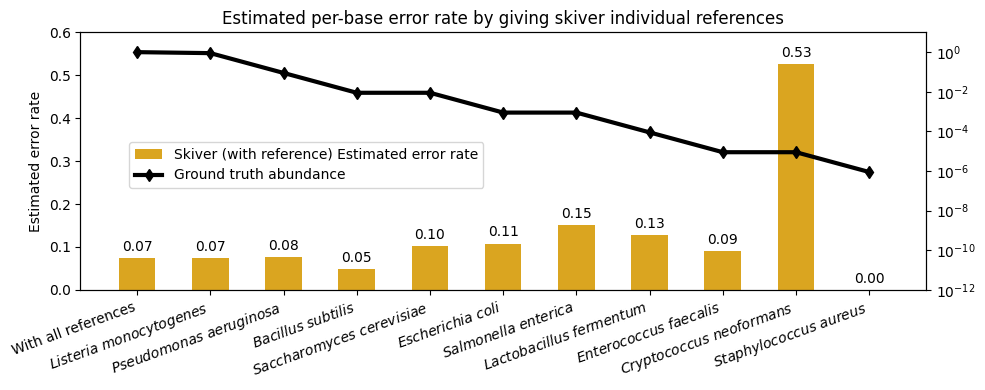

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the results: Bar plot of the identity for the full & each isolate, along with two line plots for the number of alignments (normalized by the total number of alignments) and theoretical abundance in log scale.
plt.rcParams['font.family'] = 'sans serif'
x = np.arange(len(isolate_names) + 1)  # the label locations
width = 0.5  # the width of the bars
fig, ax1 = plt.subplots(figsize=(10, 4))
bars = ax1.bar(x, [error_full] + error_rate_list, width, color='goldenrod', label='Skiver (with reference) Estimated error rate')
ax1.set_ylabel('Estimated error rate')
ax1.set_xticks(x)
ax1.set_xticklabels(['With all references'] + isolate_names, rotation=20, ha='right')
ax1.tick_params(axis='y')
ax1.set_ylim(0, 0.6)
ax1.bar_label(bars, fmt='%.2f', padding=3)
ax1.set_title('Estimated per-base error rate by giving skiver individual references')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

line2, = ax2.plot(x, [1.0] + theoretical_abundance, color='black', marker='d', linewidth=3, label='Ground truth abundance')
#line1, = ax2.plot(x, [1.0] + num_alignments_normalized, color='slategray', marker='o', linestyle='--', linewidth=3, label='% Reads mapped by Minimap2')
#ax2.set_ylabel('% Reads mapped / Theoretical Abundance')
ax2.set_yscale('log')
ax2.tick_params(axis='y')
ax2.set_ylim(1e-12, 10)
fig.legend(bbox_to_anchor=(0.5, 0.65))
fig.tight_layout()  # otherwise the right y-label is slightly clipped

plt.savefig("../../figures/skiver_zymo_vs_isolates_error_rate_ref.pdf")

## RAM usage and index size for different $k$ and $v$

In [1]:
from pathlib import Path
import re
import subprocess

import pandas as pd

experiment_dir = Path("../../output/additional_information/skiver_k_v_experiments")
log_dir = experiment_dir / "log"
name_pattern = re.compile(r"_k_(\d+)_v_(\d+)(?:\.time)?$")


def kv_from_name(path):
    match = name_pattern.search(path.name)
    if match is None:
        raise ValueError(f"Cannot extract k and v from {path}")
    return tuple(map(int, match.groups()))


# GNU time reports maximum resident set size in KiB; convert it to GiB.
ram_records = []
for time_path in sorted(log_dir.glob("*.time")):
    k, v = kv_from_name(time_path)
    text = time_path.read_text()
    match = re.search(r"Maximum resident set size \(kbytes\):\s*(\d+)", text)
    if match:
        ram_records.append({"k": k, "v": v, "RAM (GiB)": int(match.group(1)) / 1024**2})

ram_table = (pd.DataFrame(ram_records)
             .pivot(index="k", columns="v", values="RAM (GiB)")
             .sort_index().sort_index(axis=1))
print("Peak RAM usage (GiB)")
print(ram_table.to_string(float_format=lambda value: f"{value:.2f}"))

# Use du, as on the command line, and convert its KiB result to MiB.
size_records = []
for index_path in sorted(experiment_dir.glob("*_k_*_v_*")):
    if index_path.name.endswith(".time") or index_path.name == "log":
        continue
    k, v = kv_from_name(index_path)
    size_kib = int(subprocess.run(
        ["du", "-sk", str(index_path)], check=True, capture_output=True, text=True
    ).stdout.split()[0])
    size_records.append({"k": k, "v": v, "Index size (MiB)": size_kib / 1024})

size_table = (pd.DataFrame(size_records)
              .pivot(index="k", columns="v", values="Index size (MiB)")
              .sort_index().sort_index(axis=1))
print("\nIndex size (MiB)")
print(size_table.to_string(float_format=lambda value: f"{value:.2f}"))

Peak RAM usage (GiB)
v    11   17   23
k                
17 1.03 1.10 1.16
23 1.36 1.42 1.47
29 1.47 1.52 1.56

Index size (MiB)
v      11     17     23
k                      
17 201.16 236.95 271.62
23 226.79 261.12 294.55
29 239.94 273.45 306.13


1.0


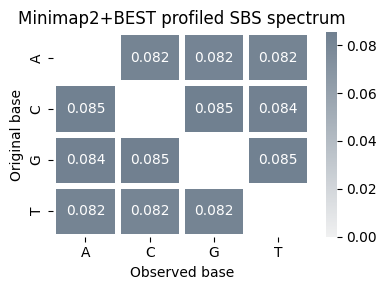

In [5]:
import pandas as pd
import numpy as np

kvmer_spectrum = "../../output/error_spectrum/Ecoli_K12_MG1655_skiver.summary_error_spectrum.csv"
minimap_result = "../../output/error_spectrum/Ecoli_K12_MG1655_depth_128_id_96.summary_sbs.csv"

kvmer_df = pd.read_csv(kvmer_spectrum)
minimap_df = pd.read_csv(minimap_result)

#cols = ["A", "C", "G", "T", "-"]
cols = ["A", "C", "G", "T"]
bases = ["A", "C", "G", "T"]



spectrum_df = pd.read_csv(minimap_result)

spectrum_matrix = np.zeros((5, 5))
for from_base in cols:
    for to_base in cols:
        if from_base == to_base:
            continue
        key = f"{from_base}>{to_base}"
        spectrum_matrix[cols.index(from_base), cols.index(to_base)] += spectrum_df[spectrum_df["substitution_type"] == key]["count"].sum()

# Normalize
spectrum_matrix /= spectrum_matrix.sum()
print(spectrum_matrix.sum())

# Plot the heatmap of sbs6 spectrum
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
mask_matrix = np.eye(4)
# also mask the diagonal
sns.heatmap(spectrum_matrix[:4,:4], annot=True, fmt=".3f", 
            xticklabels=["A", "C", "G", "T"], yticklabels=["A", "C", "G", "T"],
            linecolor="white", linewidth=3,
            vmin=0,
            mask=mask_matrix, cmap=sns.light_palette("slategray", as_cmap=True))
plt.title("Minimap2+BEST profiled SBS spectrum")
plt.ylabel("Original base")
plt.xlabel("Observed base")
plt.tight_layout()
plt.savefig("../../figures/simulated_data_sbs_spectrum_minimap.pdf")



    

## Effect of candidate count on error estimates

In [7]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

S = pd.read_csv("../../output/zymo/ERR3152366.matched_kmers.csv")["num_kmer_hit"].to_numpy()[:100]
h = np.r_[1 - S[0], 1 - S[1:] / S[:-1]]
rows = []
for path in Path("../../output/additional_information/skiver_c_experiments").glob("*.summary_error_rate.csv"):
    report = pd.read_csv(path).iloc[0]
    t = np.arange(1, len(S) + 1)
    S_hat = np.exp(-report["lambda"] * t ** report["beta"])
    h_hat = 1 - np.exp(-report["lambda"] * (t ** report["beta"] - (t - 1) ** report["beta"]))
    rows.append([int(re.search(r"_c_(\d+)", path.name)[1]), report["per_base_error_rate"], np.mean((S_hat - S) ** 2), np.mean((h_hat - h) ** 2)])

results = pd.DataFrame(rows, columns=["c", "per_base_error_rate", "MSE_S", "MSE_h"]).sort_values("c").reset_index(drop=True)
sci = lambda x: f"{float(f'{x:.2e}'.split('e')[0]):.2f} × 10^{int(f'{x:.2e}'.split('e')[1])}"
results.style.format({"per_base_error_rate": "{:.6f}", "MSE_S": sci, "MSE_h": sci})

,c,per_base_error_rate,MSE_S,MSE_h
0,3000,0.087390,2.11 × 10^-4,1.98 × 10^-5
1,6000,0.087246,1.83 × 10^-4,1.77 × 10^-5
2,12000,0.091101,9.95 × 10^-5,1.72 × 10^-5
3,24000,0.086980,1.99 × 10^-4,1.84 × 10^-5
4,48000,0.086582,2.25 × 10^-4,1.93 × 10^-5


## Effect of Illumina read trimming on error estimates

In [13]:
import csv

S = pd.read_csv("../../output/zymo/ERR2935851_ref.matched_kmers.csv")["num_kmer_hit"].to_numpy()[:100]
h, t = np.r_[1 - S[0], 1 - S[1:] / S[:-1]], np.arange(1, len(S) + 1)
rows = []
for path in Path("../../output/additional_information/skiver_trimmed_illumina").glob("*.summary_error_rate.csv"):
    report = next(csv.DictReader(path.open()))
    lambd, beta = float(report["lambda"]), float(report["beta"])
    S_hat = np.exp(-lambd * t ** beta)
    h_hat = 1 - np.exp(-lambd * (t ** beta - (t - 1) ** beta))
    rows.append([int(re.search(r"_trim_(\d+)", path.name)[1]), float(report["per_base_error_rate"]), np.mean((S_hat - S) ** 2), np.mean((h_hat - h) ** 2)])

trim_results = pd.DataFrame(rows, columns=["trimmed_bases", "per_base_error_rate", "MSE_S", "MSE_h"]).sort_values("trimmed_bases").reset_index(drop=True)
sci = lambda x: f"{float(f'{x:.4e}'.split('e')[0]):.4f} × 10^{int(f'{x:.4e}'.split('e')[1])}"
trim_results.style.format({"per_base_error_rate": "{:.6f}", "MSE_S": sci, "MSE_h": sci})

,trimmed_bases,per_base_error_rate,MSE_S,MSE_h
0,0,0.004018,6.8010 × 10^-4,2.3317 × 10^-4
1,5,0.003571,7.8597 × 10^-4,2.3330 × 10^-4
2,10,0.003392,7.3774 × 10^-4,2.3285 × 10^-4
